In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import glob
import json
import random
from collections import defaultdict, Counter
from datetime import datetime

import numpy as np
import pandas as pd
import rasterio
from tqdm import tqdm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
)
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt


2026-06-25 16:41:22.437171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782405682.706957      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782405682.785152      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782405683.370887      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782405683.370939      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782405683.370943      58 computation_placer.cc:177] computation placer alr

In [2]:
DATA_ROOT = "/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw"

N_DATES = 20
RANDOM_SEED = 42
LABEL_NAMES = ["wheat", "corn", "other"]
SOYBEAN_OTHER_COUNT = 400
RAPESEED_OTHER_COUNT = 100
REFLECTANCE_BANDS = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B09",
    "B11",
    "B12",
]
AGRI_INDEX_NAMES = ["ndvi", "evi", "ndmi", "ndwi", "ndre", "savi", "msi"]
CONTEXT_FEATURE_NAMES = ["valid_fraction", "doy_sin", "doy_cos"]
FEATURE_NAMES = REFLECTANCE_BANDS + AGRI_INDEX_NAMES + CONTEXT_FEATURE_NAMES
VALID_SCL_CLASSES = [4, 5, 6, 7]

VALID_FRACTION_INDEX = FEATURE_NAMES.index("valid_fraction")
DOY_SIN_INDEX = FEATURE_NAMES.index("doy_sin")
DOY_COS_INDEX = FEATURE_NAMES.index("doy_cos")
REFLECTANCE_FEATURE_COUNT = len(REFLECTANCE_BANDS)
AGRI_FEATURE_COUNT = len(AGRI_INDEX_NAMES)
TEMPORAL_FEATURE_COUNT = REFLECTANCE_FEATURE_COUNT + AGRI_FEATURE_COUNT

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [3]:
field_dirs = glob.glob(os.path.join(DATA_ROOT, "*", "*", "*"))

print("Number of field folders:", len(field_dirs))
print(field_dirs[:3])


Number of field folders: 2173
['/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw/Uruguay/Uruguay/Uruguay_DUP4_farm10_field515_soybean_2022', '/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw/Uruguay/Uruguay/Uruguay_DUP4_farm10_field436_soybean_2018', '/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw/Uruguay/Uruguay/Uruguay_DUP4_farm9_field269_soybean_2018']


In [4]:
fields_by_crop = defaultdict(list)
metadata_by_field = {}

for field_dir in field_dirs:
    meta_files = glob.glob(os.path.join(field_dir, "metadata-*.json"))
    if not meta_files:
        continue

    with open(meta_files[0], "r") as f:
        meta = json.load(f)

    crop = meta.get("crop", "").lower()
    fields_by_crop[crop].append(field_dir)
    metadata_by_field[field_dir] = meta

for crop, fields in fields_by_crop.items():
    print(crop, len(fields))


soybean 1305
wheat 454
corn 303
rapeseed 111


In [5]:
def country_year_key(field_dir):
    meta = metadata_by_field[field_dir]
    adm_units = meta.get("adm_units", {})
    country = adm_units.get("country", field_dir.split("/")[-3])
    year = meta.get("year")
    return f"{country}_{year}"


def stratified_sample_fields(field_list, target_count):
    if target_count >= len(field_list):
        return list(field_list)

    grouped = defaultdict(list)
    for field_dir in field_list:
        grouped[country_year_key(field_dir)].append(field_dir)

    total = sum(len(fields) for fields in grouped.values())
    quotas = {}
    remainders = []
    selected = []

    for group_key, fields in grouped.items():
        exact = target_count * len(fields) / total
        quota = min(len(fields), int(np.floor(exact)))
        quotas[group_key] = quota
        remainders.append((exact - quota, group_key))

    assigned = sum(quotas.values())
    for _, group_key in sorted(remainders, reverse=True):
        if assigned >= target_count:
            break
        if quotas[group_key] < len(grouped[group_key]):
            quotas[group_key] += 1
            assigned += 1

    for group_key, fields in grouped.items():
        quota = quotas[group_key]
        if quota > 0:
            selected.extend(random.sample(fields, quota))

    if len(selected) < target_count:
        remaining = [field for field in field_list if field not in set(selected)]
        selected.extend(random.sample(remaining, target_count - len(selected)))

    return selected


def get_label(crop):
    crop = crop.lower()
    if crop == "wheat":
        return 0
    if crop == "corn":
        return 1
    return 2


wheat_fields = fields_by_crop["wheat"]
corn_fields = fields_by_crop["corn"]
soybean_sample = stratified_sample_fields(fields_by_crop["soybean"], SOYBEAN_OTHER_COUNT)
rapeseed_sample = stratified_sample_fields(fields_by_crop["rapeseed"], RAPESEED_OTHER_COUNT)

selected_fields = wheat_fields + corn_fields + soybean_sample + rapeseed_sample
random.shuffle(selected_fields)

print("Selected fields:", len(selected_fields))
print("Wheat:", len(wheat_fields))
print("Corn:", len(corn_fields))
print("Soybean as other:", len(soybean_sample))
print("Rapeseed as other:", len(rapeseed_sample))


Selected fields: 1257
Wheat: 454
Corn: 303
Soybean as other: 400
Rapeseed as other: 100


In [6]:
def sample_dates(s2_files, n_dates=20):
    s2_files = sorted(s2_files)
    if len(s2_files) == 0:
        return []
    if len(s2_files) >= n_dates:
        idx = np.linspace(0, len(s2_files) - 1, n_dates).astype(int)
        return [s2_files[i] for i in idx]

    padded = s2_files.copy()
    while len(padded) < n_dates:
        padded.append(s2_files[-1])
    return padded


def extract_doy_features(s2_path):
    stem = os.path.splitext(os.path.basename(s2_path))[0]
    date_token = stem.replace("S2_L2A_", "")[:8]
    obs_date = datetime.strptime(date_token, "%Y%m%d")
    doy = obs_date.timetuple().tm_yday
    angle = 2.0 * np.pi * doy / 366.0
    return np.float32(np.sin(angle)), np.float32(np.cos(angle))


def find_matching_scl(s2_path):
    scl_path = (
        s2_path.replace("/s2_images/", "/scl_masks/")
        .replace("S2_L2A_", "S2_L2A_SCL_")
    )
    return scl_path if os.path.exists(scl_path) else None


def safe_ratio(num, den, eps=1e-6):
    return num / (den + eps)


def compute_agri_indices_from_means(band_means):
    b02 = band_means[REFLECTANCE_BANDS.index("B02")]
    b03 = band_means[REFLECTANCE_BANDS.index("B03")]
    b04 = band_means[REFLECTANCE_BANDS.index("B04")]
    b05 = band_means[REFLECTANCE_BANDS.index("B05")]
    b08 = band_means[REFLECTANCE_BANDS.index("B08")]
    b11 = band_means[REFLECTANCE_BANDS.index("B11")]

    ndvi = safe_ratio(b08 - b04, b08 + b04)
    evi = 2.5 * safe_ratio(b08 - b04, b08 + 6.0 * b04 - 7.5 * b02 + 1.0)
    ndmi = safe_ratio(b08 - b11, b08 + b11)
    ndwi = safe_ratio(b03 - b08, b03 + b08)
    ndre = safe_ratio(b08 - b05, b08 + b05)
    savi = 1.5 * safe_ratio(b08 - b04, b08 + b04 + 0.5)
    msi = safe_ratio(b11, b08)

    return np.array([ndvi, evi, ndmi, ndwi, ndre, savi, msi], dtype="float32")


def read_reflectance_bands_with_scl(s2_path):
    with rasterio.open(s2_path) as src:
        img = src.read().astype("float32") / 10000.0

    img[img <= 0] = np.nan
    scl_path = find_matching_scl(s2_path)
    valid_fraction = 1.0

    if scl_path is not None:
        with rasterio.open(scl_path) as src:
            scl = src.read(1)
        valid_mask = np.isin(scl, VALID_SCL_CLASSES)
        valid_fraction = float(valid_mask.mean())
        img[:, ~valid_mask] = np.nan

    band_means = []
    for band in img:
        if np.all(np.isnan(band)):
            band_means.append(np.nan)
        else:
            band_means.append(float(np.nanmean(band)))

    band_means = np.array(band_means, dtype="float32")
    agri_indices = compute_agri_indices_from_means(band_means)
    doy_sin, doy_cos = extract_doy_features(s2_path)
    return band_means, agri_indices, np.float32(valid_fraction), doy_sin, doy_cos


In [7]:
X_list = []
y_list = []
rows = []

for field_dir in tqdm(selected_fields):
    meta = metadata_by_field[field_dir]
    crop = meta["crop"].lower()
    label = get_label(crop)

    s2_files = glob.glob(os.path.join(field_dir, "s2_images", "*.tif"))
    if not s2_files:
        continue

    seq = []
    valid_fracs = []
    ok = True

    for s2_file in sample_dates(s2_files, N_DATES):
        try:
            band_means, agri_indices, valid_fraction, doy_sin, doy_cos = read_reflectance_bands_with_scl(s2_file)
            seq.append(
                np.concatenate(
                    [
                        band_means,
                        agri_indices,
                        np.array([valid_fraction, doy_sin, doy_cos], dtype="float32"),
                    ]
                )
            )
            valid_fracs.append(float(valid_fraction))
        except Exception:
            ok = False
            break

    if not ok:
        continue

    seq = np.stack(seq).astype("float32")
    X_list.append(seq)
    y_list.append(label)

    adm_units = meta.get("adm_units", {})
    country = adm_units.get("country", field_dir.split("/")[-3])
    year = meta.get("year")
    rows.append({
        "field_dir": field_dir,
        "country": country,
        "year": year,
        "country_year": f"{country}_{year}",
        "farm_identifier": meta.get("farm_identifier"),
        "crop": crop,
        "label": label,
        "n_s2_images": len(s2_files),
        "n_features": seq.shape[1],
        "mean_valid_fraction": float(np.mean(valid_fracs)),
        "min_valid_fraction": float(np.min(valid_fracs)),
    })

X = np.stack(X_list)
y = np.array(y_list)
meta_df = pd.DataFrame(rows)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(meta_df["crop"].value_counts())
print(meta_df["label"].value_counts())
print(meta_df["country_year"].nunique(), "unique country_year groups")
print(meta_df["n_features"].value_counts())


100%|██████████| 1257/1257 [14:05<00:00,  1.49it/s]

X shape: (1257, 20, 22)
y shape: (1257,)
crop
wheat       454
soybean     400
corn        303
rapeseed    100
Name: count, dtype: int64
label
2    500
0    454
1    303
Name: count, dtype: int64
28 unique country_year groups
n_features
22    1257
Name: count, dtype: int64


In [8]:
feature_names = FEATURE_NAMES

print("Reflectance bands:", REFLECTANCE_BANDS)
print("Agri indices:", AGRI_INDEX_NAMES)
print("Context features:", CONTEXT_FEATURE_NAMES)
print("Feature names:", feature_names)
print("Temporal feature count:", TEMPORAL_FEATURE_COUNT)


Reflectance bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']
Agri indices: ['ndvi', 'evi', 'ndmi', 'ndwi', 'ndre', 'savi', 'msi']
Context features: ['valid_fraction', 'doy_sin', 'doy_cos']
Feature names: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'ndvi', 'evi', 'ndmi', 'ndwi', 'ndre', 'savi', 'msi', 'valid_fraction', 'doy_sin', 'doy_cos']
Temporal feature count: 19


In [9]:
def fill_nan_temporal_features(X_data, temporal_feature_count):
    X_filled = X_data.copy()
    for i in range(X_data.shape[0]):
        for b in range(temporal_feature_count):
            s = pd.Series(X_data[i, :, b]).interpolate(method="linear", limit_direction="both")
            if s.isna().any():
                s = s.fillna(s.median())
            X_filled[i, :, b] = s.values
    return X_filled


print("NaNs before:", np.isnan(X).sum())
X_clean = fill_nan_temporal_features(X, TEMPORAL_FEATURE_COUNT)
print("NaNs after temporal fill:", np.isnan(X_clean).sum())

if np.isnan(X_clean[:, :, :TEMPORAL_FEATURE_COUNT]).sum() > 0:
    global_medians = np.nanmedian(X_clean[:, :, :TEMPORAL_FEATURE_COUNT], axis=(0, 1))
    for b in range(TEMPORAL_FEATURE_COUNT):
        X_clean[:, :, b] = np.where(
            np.isnan(X_clean[:, :, b]),
            global_medians[b],
            X_clean[:, :, b],
        )

X_clean[:, :, VALID_FRACTION_INDEX] = np.clip(np.nan_to_num(X_clean[:, :, VALID_FRACTION_INDEX], nan=0.0), 0.0, 1.0)
X_clean[:, :, DOY_SIN_INDEX] = np.nan_to_num(X_clean[:, :, DOY_SIN_INDEX], nan=0.0)
X_clean[:, :, DOY_COS_INDEX] = np.nan_to_num(X_clean[:, :, DOY_COS_INDEX], nan=1.0)

print("NaNs final:", np.isnan(X_clean).sum())
print("Temporal feature min:", np.nanmin(X_clean[:, :, :TEMPORAL_FEATURE_COUNT]))
print("Temporal feature max:", np.nanmax(X_clean[:, :, :TEMPORAL_FEATURE_COUNT]))
print("Valid fraction min:", np.nanmin(X_clean[:, :, VALID_FRACTION_INDEX]))
print("Valid fraction max:", np.nanmax(X_clean[:, :, VALID_FRACTION_INDEX]))


NaNs before: 174876
NaNs after temporal fill: 0
NaNs final: 0
Temporal feature min: -9.391356
Temporal feature max: 12.874975
Valid fraction min: 0.0
Valid fraction max: 1.0


In [10]:
df_sample = pd.DataFrame(X_clean[0], columns=feature_names)
df_sample["time_step"] = range(1, N_DATES + 1)
df_sample["crop"] = meta_df.iloc[0]["crop"]
df_sample["label"] = meta_df.iloc[0]["label"]

df_sample


,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,...,ndwi,ndre,savi,msi,valid_fraction,doy_sin,doy_cos,time_step,crop,label
0,0.174894,0.067326,0.095503,0.107681,0.146182,0.187001,0.203057,0.144424,0.222286,0.305858,...,-0.203898,-0.006051,0.073280,1.319825,0.000000,-0.980575,-0.196143,1,wheat,0
1,0.174894,0.067326,0.095503,0.107681,0.146182,0.187001,0.203057,0.144424,0.222286,0.305858,...,-0.203898,-0.006051,0.073280,1.319825,0.000000,-0.980575,0.196143,2,wheat,0
2,0.174894,0.067326,0.095503,0.107681,0.146182,0.187001,0.203057,0.144424,0.222286,0.305858,...,-0.203898,-0.006051,0.073280,1.319825,0.103784,-0.882679,0.469977,3,wheat,0
3,0.118370,0.105749,0.114973,0.110380,0.127354,0.147715,0.151057,0.158592,0.153416,0.138985,...,-0.159445,0.109241,0.094044,0.819707,0.496216,-0.756771,0.653681,4,wheat,0
4,0.108918,0.097208,0.107461,0.102167,0.121506,0.159138,0.172031,0.181059,0.175892,0.162919,...,-0.227050,0.170091,0.143841,0.769061,0.000000,-0.492548,0.870285,5,wheat,0
5,0.099465,0.088666,0.099950,0.093953,0.115657,0.170561,0.193004,0.203526,0.198367,0.186853,...,-0.294655,0.230940,0.193638,0.718416,0.000000,-0.221325,0.975200,6,wheat,0
6,0.090013,0.080124,0.092438,0.085740,0.109808,0.181984,0.213977,0.225994,0.220843,0.210788,...,-0.362260,0.291790,0.243435,0.667771,0.000000,0.119881,0.992788,7,wheat,0
7,0.080560,0.071583,0.084927,0.077526,0.103959,0.193407,0.234951,0.248461,0.243318,0.234722,...,-0.429864,0.352640,0.293232,0.617125,0.000000,0.492548,0.870285,8,wheat,0
8,0.071108,0.063041,0.077416,0.069313,0.098110,0.204830,0.255924,0.270929,0.265794,0.258656,...,-0.497469,0.413490,0.343030,0.566480,0.000000,0.756771,0.653681,9,wheat,0
9,0.061656,0.054500,0.069904,0.061099,0.092261,0.216253,0.276898,0.293396,0.288270,0.282590,...,-0.565074,0.474340,0.392827,0.515835,0.000000,0.912846,0.408304,10,wheat,0


In [11]:
group_labels = meta_df["country_year"].values

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
train_idx, test_idx = next(outer_cv.split(X_clean, y, groups=group_labels))

X_train, X_test = X_clean[train_idx], X_clean[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
train_group_labels = group_labels[train_idx]

print("Train:", X_train.shape, Counter(y_train))
print("Test:", X_test.shape, Counter(y_test))
print("Train groups:", len(np.unique(train_group_labels)))
print("Test groups:", len(np.unique(group_labels[test_idx])))


Train: (1028, 20, 22) Counter({np.int64(2): 411, np.int64(0): 370, np.int64(1): 247})
Test: (229, 20, 22) Counter({np.int64(2): 89, np.int64(0): 84, np.int64(1): 56})
Train groups: 22
Test groups: 6


In [12]:
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_SEED)
tr_idx, val_idx = next(inner_cv.split(X_train, y_train, groups=train_group_labels))

X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print("Train final:", X_tr.shape, Counter(y_tr))
print("Validation:", X_val.shape, Counter(y_val))
print("Validation groups:", len(np.unique(train_group_labels[val_idx])))


Train final: (750, 20, 22) Counter({np.int64(2): 314, np.int64(0): 223, np.int64(1): 213})
Validation: (278, 20, 22) Counter({np.int64(0): 147, np.int64(2): 97, np.int64(1): 34})
Validation groups: 6


In [13]:
scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr.reshape(-1, X_tr.shape[-1])).reshape(X_tr.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

print("X_tr_scaled:", X_tr_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Scaled feature count:", X_tr_scaled.shape[-1])


X_tr_scaled: (750, 20, 22)
X_val_scaled: (278, 20, 22)
X_test_scaled: (229, 20, 22)
Scaled feature count: 22


In [14]:
n_timesteps = X_tr_scaled.shape[1]
n_features = X_tr_scaled.shape[2]
n_classes = len(np.unique(y))

model = models.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),
    layers.LayerNormalization(),
    layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(48, return_sequences=True, dropout=0.2)),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


2026-06-25 16:56:41.797500: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_normalization             │ (None, 20, 22)         │            44 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 20, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 96)         │        43,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,127 (211.43 KB)

 Trainable params: 54,127 (211.43 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1)

history = model.fit(
    X_tr_scaled,
    y_tr,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.5933 - loss: 0.9290 - val_accuracy: 0.8489 - val_loss: 0.6459 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7987 - loss: 0.5378 - val_accuracy: 0.8273 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8293 - loss: 0.4137 - val_accuracy: 0.8165 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8707 - loss: 0.3358 - val_accuracy: 0.8705 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8720 - loss: 0.3069 - val_accuracy: 0.8741 - val_loss: 0.2917 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8800 - loss: 0.2752 - val_accuracy: 0.9137 - val_loss: 0.2309 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9173 - loss: 0.2146 - 

In [16]:
lstm_val_probs = model.predict(X_val_scaled)
lstm_test_probs = model.predict(X_test_scaled)

lstm_val_pred = np.argmax(lstm_val_probs, axis=1)
lstm_test_pred = np.argmax(lstm_test_probs, axis=1)

print("LSTM Validation macro F1:", f1_score(y_val, lstm_val_pred, average="macro"))
print("LSTM Test Accuracy:", accuracy_score(y_test, lstm_test_pred))
print(confusion_matrix(y_test, lstm_test_pred))
print(classification_report(y_test, lstm_test_pred, target_names=LABEL_NAMES))


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
LSTM Validation macro F1: 0.9443226115256497
LSTM Test Accuracy: 0.9475982532751092
[[81  1  2]
 [ 1 55  0]
 [ 1  7 81]]
              precision    recall  f1-score   support

       wheat       0.98      0.96      0.97        84
        corn       0.87      0.98      0.92        56
       other       0.98      0.91      0.94        89

    accuracy                           0.95       229
   macro avg       0.94      0.95      0.95       229
weighted avg       0.95      0.95      0.95       229



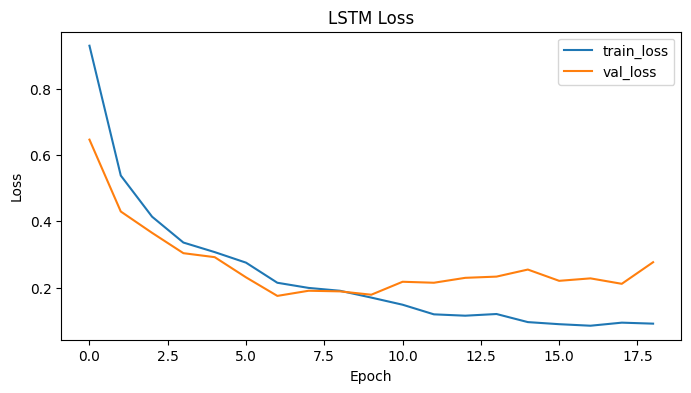

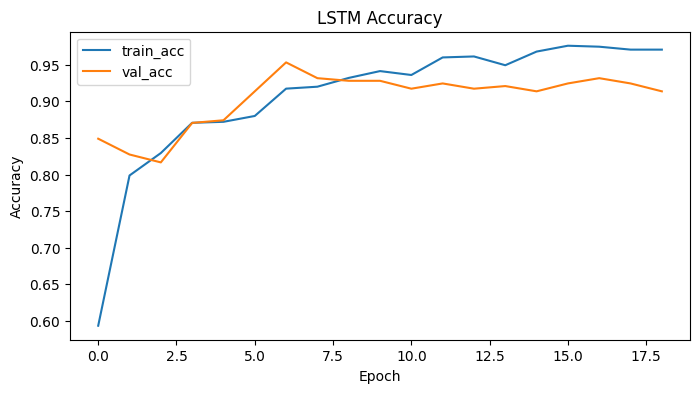

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [18]:
def lstm_permutation_importance(model, X_eval, y_eval, feature_names, n_repeats=5, random_state=RANDOM_SEED):
    rng = np.random.default_rng(random_state)
    baseline_pred = np.argmax(model.predict(X_eval, verbose=0), axis=1)
    baseline_macro_f1 = f1_score(y_eval, baseline_pred, average="macro")

    rows = []
    n_samples = X_eval.shape[0]
    for feature_idx, feature_name in enumerate(feature_names):
        repeat_scores = []
        for _ in range(n_repeats):
            X_perm = X_eval.copy()
            perm_idx = rng.permutation(n_samples)
            X_perm[:, :, feature_idx] = X_perm[perm_idx, :, feature_idx]
            perm_pred = np.argmax(model.predict(X_perm, verbose=0), axis=1)
            perm_macro_f1 = f1_score(y_eval, perm_pred, average="macro")
            repeat_scores.append(baseline_macro_f1 - perm_macro_f1)

        rows.append({
            "feature": feature_name,
            "baseline_macro_f1": float(baseline_macro_f1),
            "importance_mean": float(np.mean(repeat_scores)),
            "importance_std": float(np.std(repeat_scores)),
        })

    return pd.DataFrame(rows).sort_values("importance_mean", ascending=False)


lstm_importance_df = lstm_permutation_importance(model, X_test_scaled, y_test, feature_names, n_repeats=5)
lstm_importance_df.head(20)


,feature,baseline_macro_f1,importance_mean,importance_std
21,doy_cos,0.94543,0.251532,0.021656
20,doy_sin,0.94543,0.206689,0.011577
5,B06,0.94543,0.154242,0.013666
16,ndre,0.94543,0.056551,0.009595
10,B11,0.94543,0.050650,0.016533
14,ndmi,0.94543,0.024759,0.008968
18,msi,0.94543,0.015859,0.009377
6,B07,0.94543,0.012454,0.003514
9,B09,0.94543,0.009564,0.008033
13,evi,0.94543,0.009530,0.004879


In [19]:
feature_groups = {
    "reflectance": REFLECTANCE_BANDS,
    "agri_indices": AGRI_INDEX_NAMES,
    "context": CONTEXT_FEATURE_NAMES,
}


def lstm_group_permutation_importance(model, X_eval, y_eval, feature_names, feature_groups, n_repeats=5, random_state=RANDOM_SEED):
    rng = np.random.default_rng(random_state)
    baseline_pred = np.argmax(model.predict(X_eval, verbose=0), axis=1)
    baseline_macro_f1 = f1_score(y_eval, baseline_pred, average="macro")

    rows = []
    n_samples = X_eval.shape[0]
    feature_index = {name: idx for idx, name in enumerate(feature_names)}

    for group_name, names in feature_groups.items():
        indices = [feature_index[name] for name in names]
        repeat_scores = []
        for _ in range(n_repeats):
            X_perm = X_eval.copy()
            perm_idx = rng.permutation(n_samples)
            X_perm[:, :, indices] = X_perm[perm_idx][:, :, indices]
            perm_pred = np.argmax(model.predict(X_perm, verbose=0), axis=1)
            perm_macro_f1 = f1_score(y_eval, perm_pred, average="macro")
            repeat_scores.append(baseline_macro_f1 - perm_macro_f1)

        rows.append({
            "group": group_name,
            "baseline_macro_f1": float(baseline_macro_f1),
            "importance_mean": float(np.mean(repeat_scores)),
            "importance_std": float(np.std(repeat_scores)),
        })

    return pd.DataFrame(rows).sort_values("importance_mean", ascending=False)


lstm_group_importance_df = lstm_group_permutation_importance(
    model,
    X_test_scaled,
    y_test,
    feature_names,
    feature_groups,
    n_repeats=5,
)
lstm_group_importance_df


,group,baseline_macro_f1,importance_mean,importance_std
2,context,0.94543,0.386634,0.006367
0,reflectance,0.94543,0.283879,0.025576
1,agri_indices,0.94543,0.152648,0.011684


In [20]:
low_lstm_importance_df = lstm_importance_df[lstm_importance_df["importance_mean"] <= 0.002].copy()
print("Candidate low-importance LSTM features:")
low_lstm_importance_df


Candidate low-importance LSTM features:


,feature,baseline_macro_f1,importance_mean,importance_std
15,ndwi,0.94543,0.001725,0.004482
19,valid_fraction,0.94543,0.000850,0.011221
3,B04,0.94543,0.000423,0.001839
2,B03,0.94543,-0.000701,0.003878
4,B05,0.94543,-0.001075,0.004597
12,ndvi,0.94543,-0.001880,0.006080
1,B02,0.94543,-0.002710,0.004367
7,B08,0.94543,-0.003893,0.006732
11,B12,0.94543,-0.004404,0.004808
8,B8A,0.94543,-0.005516,0.007617


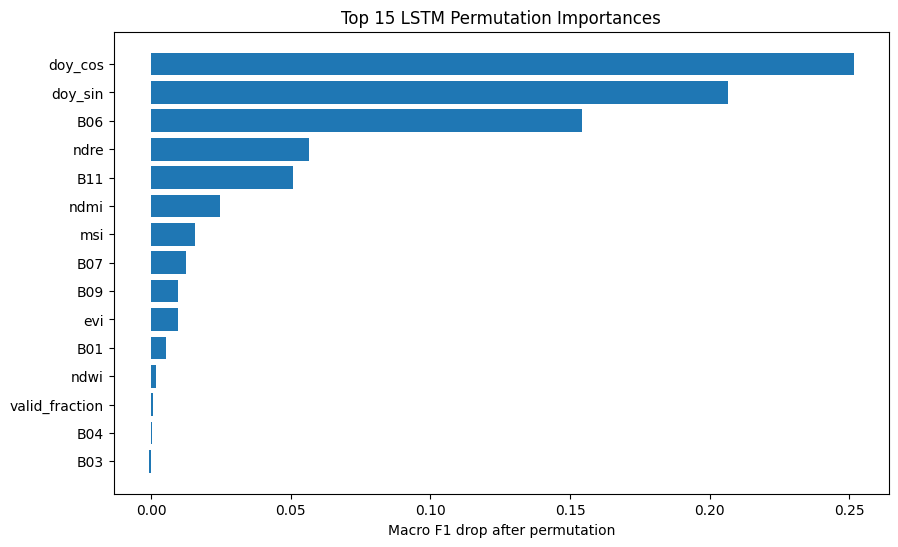

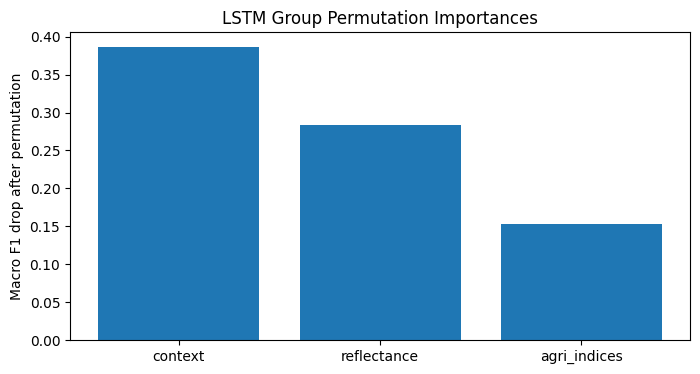

In [21]:
top_lstm = lstm_importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_lstm["feature"], top_lstm["importance_mean"])
plt.title("Top 15 LSTM Permutation Importances")
plt.xlabel("Macro F1 drop after permutation")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(lstm_group_importance_df["group"], lstm_group_importance_df["importance_mean"])
plt.title("LSTM Group Permutation Importances")
plt.ylabel("Macro F1 drop after permutation")
plt.show()


In [22]:
from xgboost import XGBClassifier

X_tr_flat = X_tr_scaled.reshape(X_tr_scaled.shape[0], -1)
X_val_flat = X_val_scaled.reshape(X_val_scaled.shape[0], -1)
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_lambda=1.5,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_SEED,
)

xgb.fit(X_tr_flat, y_tr, eval_set=[(X_val_flat, y_val)], verbose=False)

xgb_val_probs = xgb.predict_proba(X_val_flat)
xgb_test_probs = xgb.predict_proba(X_test_flat)
xgb_test_pred = np.argmax(xgb_test_probs, axis=1)

print("XGBoost Validation macro F1:", f1_score(y_val, np.argmax(xgb_val_probs, axis=1), average="macro"))
print("XGBoost Test Accuracy:", accuracy_score(y_test, xgb_test_pred))
print(confusion_matrix(y_test, xgb_test_pred))
print(classification_report(y_test, xgb_test_pred, target_names=LABEL_NAMES))


XGBoost Validation macro F1: 0.8846232115462884
XGBoost Test Accuracy: 0.9170305676855895
[[84  0  0]
 [ 0 55  1]
 [17  1 71]]
              precision    recall  f1-score   support

       wheat       0.83      1.00      0.91        84
        corn       0.98      0.98      0.98        56
       other       0.99      0.80      0.88        89

    accuracy                           0.92       229
   macro avg       0.93      0.93      0.92       229
weighted avg       0.93      0.92      0.92       229



In [23]:
def predict_with_target_thresholds(probs, wheat_threshold, corn_threshold):
    preds = np.full(probs.shape[0], 2, dtype=int)
    wheat_mask = probs[:, 0] >= wheat_threshold
    corn_mask = probs[:, 1] >= corn_threshold

    for i in range(probs.shape[0]):
        if wheat_mask[i] and corn_mask[i]:
            preds[i] = 0 if probs[i, 0] >= probs[i, 1] else 1
        elif wheat_mask[i]:
            preds[i] = 0
        elif corn_mask[i]:
            preds[i] = 1

    return preds


best_config = None
best_score = -np.inf

for alpha in np.linspace(0.0, 1.0, 11):
    val_probs = alpha * lstm_val_probs + (1.0 - alpha) * xgb_val_probs
    for wheat_threshold in np.linspace(0.35, 0.75, 9):
        for corn_threshold in np.linspace(0.35, 0.85, 11):
            val_pred = predict_with_target_thresholds(val_probs, wheat_threshold, corn_threshold)
            macro_f1 = f1_score(y_val, val_pred, average="macro")
            wheat_precision = precision_score(y_val, val_pred, labels=[0], average="macro", zero_division=0)
            corn_precision = precision_score(y_val, val_pred, labels=[1], average="macro", zero_division=0)
            score = macro_f1 + 0.05 * wheat_precision + 0.10 * corn_precision
            if score > best_score:
                best_score = score
                best_config = {
                    "alpha": float(alpha),
                    "wheat_threshold": float(wheat_threshold),
                    "corn_threshold": float(corn_threshold),
                    "macro_f1": float(macro_f1),
                    "wheat_precision": float(wheat_precision),
                    "corn_precision": float(corn_precision),
                }

print("Best validation config:", best_config)

final_test_probs = best_config["alpha"] * lstm_test_probs + (1.0 - best_config["alpha"]) * xgb_test_probs
final_test_pred = predict_with_target_thresholds(
    final_test_probs,
    best_config["wheat_threshold"],
    best_config["corn_threshold"],
)

print("Final tuned ensemble accuracy:", accuracy_score(y_test, final_test_pred))
print("Final tuned ensemble macro F1:", f1_score(y_test, final_test_pred, average="macro"))
print(confusion_matrix(y_test, final_test_pred))
print(classification_report(y_test, final_test_pred, target_names=LABEL_NAMES))


Best validation config: {'alpha': 0.7000000000000001, 'wheat_threshold': 0.6, 'corn_threshold': 0.75, 'macro_f1': 0.963821892393321, 'wheat_precision': 0.9727891156462585, 'corn_precision': 1.0}
Final tuned ensemble accuracy: 0.9781659388646288
Final tuned ensemble macro F1: 0.979644427354021
[[82  0  2]
 [ 1 55  0]
 [ 2  0 87]]
              precision    recall  f1-score   support

       wheat       0.96      0.98      0.97        84
        corn       1.00      0.98      0.99        56
       other       0.98      0.98      0.98        89

    accuracy                           0.98       229
   macro avg       0.98      0.98      0.98       229
weighted avg       0.98      0.98      0.98       229



In [24]:
def build_field_level_agri_table(X_data, feature_names):
    rows = []
    ndvi_idx = feature_names.index("ndvi")
    ndmi_idx = feature_names.index("ndmi")
    valid_idx = feature_names.index("valid_fraction")

    for sample in X_data:
        row = {}
        for feature_idx, feature_name in enumerate(feature_names):
            values = sample[:, feature_idx]
            row[f"{feature_name}_mean"] = float(np.mean(values))
            row[f"{feature_name}_std"] = float(np.std(values))
            row[f"{feature_name}_min"] = float(np.min(values))
            row[f"{feature_name}_max"] = float(np.max(values))

        ndvi_series = sample[:, ndvi_idx]
        ndmi_series = sample[:, ndmi_idx]
        valid_series = sample[:, valid_idx]
        row["ndvi_amplitude"] = float(np.max(ndvi_series) - np.min(ndvi_series))
        row["ndvi_auc"] = float(np.trapezoid(ndvi_series))
        row["ndvi_peak_timestep"] = int(np.argmax(ndvi_series))
        row["ndmi_amplitude"] = float(np.max(ndmi_series) - np.min(ndmi_series))
        row["valid_fraction_auc"] = float(np.trapezoid(valid_series))
        row["valid_fraction_low_obs_count"] = int(np.sum(valid_series < 0.25))
        rows.append(row)

    return pd.DataFrame(rows)


field_feature_df = pd.concat(
    [meta_df.reset_index(drop=True), build_field_level_agri_table(X_clean, feature_names)],
    axis=1,
)

print(field_feature_df.shape)
field_feature_df.head()


(1257, 105)


,field_dir,country,year,country_year,farm_identifier,crop,label,n_s2_images,n_features,mean_valid_fraction,...,doy_cos_mean,doy_cos_std,doy_cos_min,doy_cos_max,ndvi_amplitude,ndvi_auc,ndvi_peak_timestep,ndmi_amplitude,valid_fraction_auc,valid_fraction_low_obs_count
0,/kaggle/input/datasets/abdulhamedeid/yieldsat-...,Germany,2017,Germany_2017,farm2,wheat,0,63,22,0.172270,...,-0.053010,0.745766,-0.997643,0.992788,0.753253,8.843114,13,0.636815,3.441081,15
1,/kaggle/input/datasets/abdulhamedeid/yieldsat-...,Germany,2021,Germany_2021,farm2,wheat,0,115,22,0.188098,...,0.095502,0.737288,-0.997643,0.997643,0.562945,9.207376,16,0.536410,3.761951,15
2,/kaggle/input/datasets/abdulhamedeid/yieldsat-...,Germany,2022,Germany_2022,farm2,wheat,0,108,22,0.192910,...,0.098121,0.752513,-0.992788,0.994700,0.562473,11.238480,16,0.545459,3.356225,12
3,/kaggle/input/datasets/abdulhamedeid/yieldsat-...,Uruguay,2018,Uruguay_2018,farm7,soybean,2,24,22,0.687584,...,0.635724,0.346360,-0.128398,0.997643,0.429697,9.162615,9,0.353793,12.751675,6
4,/kaggle/input/datasets/abdulhamedeid/yieldsat-...,Uruguay,2018,Uruguay_2018,farm7,soybean,2,28,22,0.721221,...,0.497830,0.464884,-0.454755,0.992788,0.426070,9.108670,13,0.403454,13.924418,5


In [25]:
agg_feature_cols = [
    col for col in field_feature_df.columns
    if col not in {"field_dir", "country", "year", "country_year", "farm_identifier", "crop", "label"}
]

X_tr_agg = field_feature_df.iloc[train_idx].iloc[tr_idx][agg_feature_cols]
X_val_agg = field_feature_df.iloc[train_idx].iloc[val_idx][agg_feature_cols]
X_test_agg = field_feature_df.iloc[test_idx][agg_feature_cols]

agg_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_lambda=1.5,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_SEED,
)

agg_xgb.fit(X_tr_agg, y_tr, eval_set=[(X_val_agg, y_val)], verbose=False)

agg_val_probs = agg_xgb.predict_proba(X_val_agg)
agg_test_probs = agg_xgb.predict_proba(X_test_agg)
agg_test_pred = np.argmax(agg_test_probs, axis=1)

print("Agg XGBoost Validation macro F1:", f1_score(y_val, np.argmax(agg_val_probs, axis=1), average="macro"))
print("Agg XGBoost Test Accuracy:", accuracy_score(y_test, agg_test_pred))
print(confusion_matrix(y_test, agg_test_pred))
print(classification_report(y_test, agg_test_pred, target_names=LABEL_NAMES))


Agg XGBoost Validation macro F1: 0.8832364341085271
Agg XGBoost Test Accuracy: 0.8122270742358079
[[73  8  3]
 [ 7 48  1]
 [19  5 65]]
              precision    recall  f1-score   support

       wheat       0.74      0.87      0.80        84
        corn       0.79      0.86      0.82        56
       other       0.94      0.73      0.82        89

    accuracy                           0.81       229
   macro avg       0.82      0.82      0.81       229
weighted avg       0.83      0.81      0.81       229



In [26]:
importance_df = pd.DataFrame({
    "feature": agg_feature_cols,
    "gain_importance": agg_xgb.feature_importances_,
}).sort_values("gain_importance", ascending=False)

perm = permutation_importance(
    agg_xgb,
    X_test_agg,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring="f1_macro",
)
perm_df = pd.DataFrame({
    "feature": agg_feature_cols,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

importance_df.head(20)


,feature,gain_importance
83,valid_fraction_max,0.109326
90,doy_cos_min,0.100012
88,doy_cos_mean,0.049839
94,ndvi_peak_timestep,0.040818
86,doy_sin_min,0.032193
84,doy_sin_mean,0.031498
85,doy_sin_std,0.024753
96,valid_fraction_auc,0.024741
40,B09_mean,0.023534
77,msi_std,0.023382


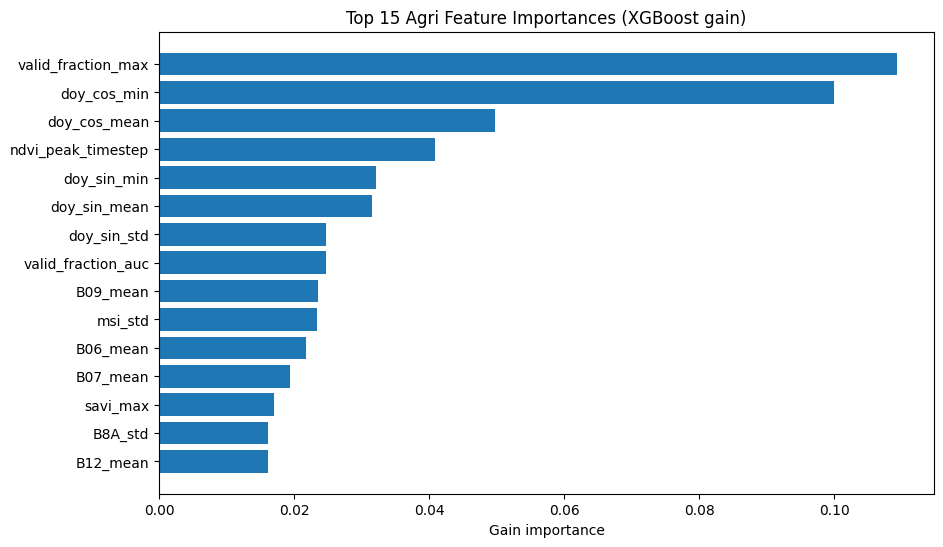

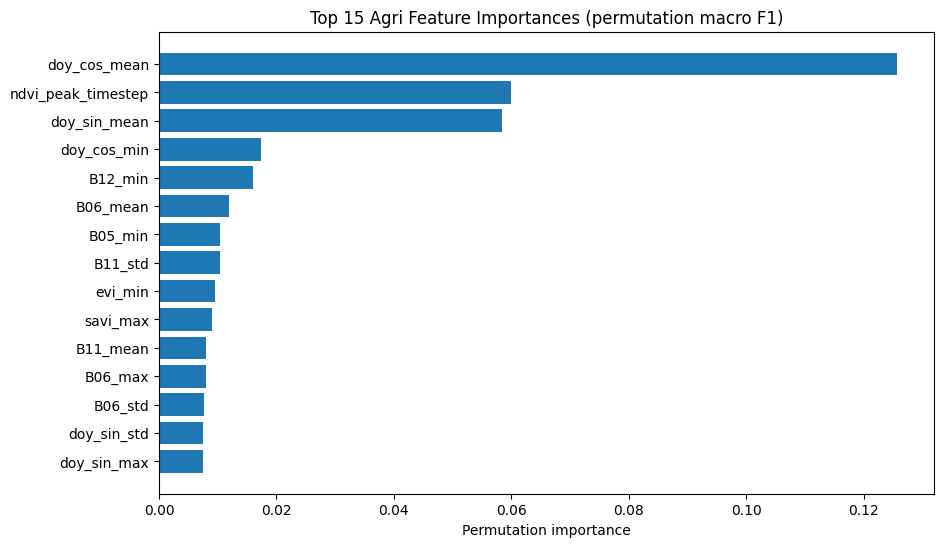

In [27]:
top_gain = importance_df.head(15).iloc[::-1]
top_perm = perm_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_gain["feature"], top_gain["gain_importance"])
plt.title("Top 15 Agri Feature Importances (XGBoost gain)")
plt.xlabel("Gain importance")
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(top_perm["feature"], top_perm["perm_importance_mean"])
plt.title("Top 15 Agri Feature Importances (permutation macro F1)")
plt.xlabel("Permutation importance")
plt.show()


In [ ]:
import os
import json
import shutil
import joblib

SAVE_DIR = "saved_full_features_lstm_model"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "lstm_crop_classifier.keras"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))
joblib.dump(feature_names, os.path.join(SAVE_DIR, "feature_names.pkl"))
joblib.dump(LABEL_NAMES, os.path.join(SAVE_DIR, "label_names.pkl"))

config = {
    "model_name": "full_features_lstm",
    "task": "field_level_crop_classification",
    "labels": LABEL_NAMES,
    "n_timesteps": int(X_tr_scaled.shape[1]),
    "n_features": int(X_tr_scaled.shape[2]),
    "feature_names": feature_names,
    "input_shape": [int(X_tr_scaled.shape[1]), int(X_tr_scaled.shape[2])],
}

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

np.save("X_wheat_corn_other_reflectance_agri_calendar_quality.npy", X_clean)
np.save("y_wheat_corn_other.npy", y)
meta_df.to_csv("metadata_wheat_corn_other_country_year.csv", index=False)
field_feature_df.to_csv("field_level_agri_features.csv", index=False)
importance_df.to_csv("agri_feature_importance_gain.csv", index=False)
perm_df.to_csv("agri_feature_importance_permutation.csv", index=False)
lstm_importance_df.to_csv("lstm_feature_importance_permutation.csv", index=False)
lstm_group_importance_df.to_csv("lstm_group_importance_permutation.csv", index=False)

shutil.make_archive(SAVE_DIR, "zip", SAVE_DIR)

print("Saved full-feature notebook outputs and LSTM package:")
print(sorted(os.listdir(SAVE_DIR)))
print(f"{SAVE_DIR}.zip")


In [29]:
print(field_feature_df[["country_year", "mean_valid_fraction"]].groupby("country_year").agg(["count", "mean"]).sort_index())


               mean_valid_fraction          
                             count      mean
country_year                                
Argentina_2017                  17  0.256831
Argentina_2018                  29  0.382625
Argentina_2019                  24  0.426213
Argentina_2020                  67  0.423318
Argentina_2021                 100  0.433858
Argentina_2022                 107  0.352923
Argentina_2023                  76  0.322695
Argentina_2024                  26  0.284130
Brazil_2017                     36  0.244213
Brazil_2018                     48  0.235501
Brazil_2019                     53  0.287547
Brazil_2020                     47  0.314607
Brazil_2021                     32  0.247554
Brazil_2022                     34  0.267818
Brazil_2023                     69  0.235642
Brazil_2024                     29  0.276176
Germany_2016                    46  0.252636
Germany_2017                    53  0.196811
Germany_2018                    44  0.262049
Germany_20

In [30]:
print("Unique country_year groups:", meta_df["country_year"].nunique())


Unique country_year groups: 28
